In [24]:
# =========================================
# LSTM for On-Peak Hourly Price Prediction
# =========================================
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------
# 1) Load & prepare data
# -------------------------
CSV_PATH = "/content/Monthly_On_Peak_Totals.csv"  # change if needed
df = pd.read_csv(CSV_PATH, low_memory=False)

# Keep only what's needed
assert "Month" in df.columns and "Total Price" in df.columns, "Expected columns 'Month' and 'Total Price' not found."
df = df[["Month", "Total Price"]].copy()

# Parse datetime, sort, set index
df["Month"] = pd.to_datetime(df["Month"], errors="coerce")
df = df.dropna(subset=["Month"]).sort_values("Month").set_index("Month")

# Resample to hourly, average if multiple points within the hour; interpolate missing
df = df.resample("H").mean()
df["Total Price"] = df["Total Price"].interpolate(method="time").ffill().bfill()

# -------------------------
# 2) Train / test split
# -------------------------
SPLIT = 0.8  # last 20% for test
split_idx = int(len(df) * SPLIT)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

# Scale (fit on train only)
scaler_y = MinMaxScaler()
y_train = scaler_y.fit_transform(train_df[["Total Price"]])
y_test  = scaler_y.transform(test_df[["Total Price"]])

# -------------------------
# 3) Make supervised sequences
# -------------------------
LOOKBACK = 24 * 7  # 168 hours (one week history)

def make_sequences(series_2d, lookback):
    X, y = [], []
    for i in range(lookback, len(series_2d)):
        X.append(series_2d[i-lookback:i, :])
        y.append(series_2d[i, :])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(y_train, LOOKBACK)
X_test,  y_test  = make_sequences(y_test,  LOOKBACK)

print(f"Train sequences: X={X_train.shape}, y={y_train.shape}")
print(f"Test  sequences: X={X_test.shape},  y={y_test.shape}")

# -------------------------
# 4) Build & train model
# -------------------------
tf.random.set_seed(42); np.random.seed(42)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")

es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[es],
    verbose=1
)

# -------------------------
# 5) Evaluate on test set
# -------------------------
y_pred_s = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_s).ravel()
y_true = scaler_y.inverse_transform(y_test).ravel()

mae  = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)
mape = (np.abs((y_true - y_pred) / (y_true + 1e-8))).mean() * 100

print(f"MAE : {mae:,.3f}")
print(f"RMSE: {rmse:,.3f}")
print(f"MAPE: {mape:,.2f}%")

# Match with datetime index for plotting
test_index = test_df.index[LOOKBACK:]  # align to y_test
plot_df = pd.DataFrame({"Actual": y_true, "Predicted": y_pred}, index=test_index)

plt.figure()
plt.plot(plot_df.index, plot_df["Actual"], label="Actual")
plt.plot(plot_df.index, plot_df["Predicted"], label="Predicted")
plt.xlabel("Date"); plt.ylabel("Price ($/MWh)")
plt.title("On-Peak LSTM — Actual vs Predicted (Test)")
plt.legend(); plt.tight_layout(); plt.show()

# -------------------------
# 6) Forecast next 168 hours
# -------------------------
FORECAST_HOURS = 168
last_window = scaler_y.transform(df[["Total Price"]].iloc[-LOOKBACK:].values)  # shape (168, 1)
window = last_window.copy()
future_scaled = []

for _ in range(FORECAST_HOURS):
    inp = window.reshape(1, LOOKBACK, 1)
    next_scaled = model.predict(inp, verbose=0)[0, 0]
    future_scaled.append(next_scaled)
    # roll window
    window = np.vstack([window[1:], [[next_scaled]]])

future_prices = scaler_y.inverse_transform(np.array(future_scaled).reshape(-1,1)).ravel()

future_index = pd.date_range(df.index[-1] + pd.Timedelta(hours=1), periods=FORECAST_HOURS, freq="H")
forecast_df = pd.DataFrame({"Forecast_Price": future_prices}, index=future_index)

plt.figure()
plt.plot(df.index[-7*24:], df["Total Price"].iloc[-7*24:], label="Recent Actual (last 7 days)")
plt.plot(forecast_df.index, forecast_df["Forecast_Price"], label="Forecast (next 7 days)")
plt.xlabel("Date"); plt.ylabel("Price ($/MWh)")
plt.title("On-Peak Price — 7-Day Hourly Forecast")
plt.legend(); plt.tight_layout(); plt.show()

# -------------------------
# 7) Save artifacts
# -------------------------
OUT_DIR = "/mnt/data/On_Peak_LSTM_Output"
os.makedirs(OUT_DIR, exist_ok=True)
model.save(os.path.join(OUT_DIR, "on_peak_model.keras"))
pd.DataFrame({"min_": scaler_y.min_, "scale_": scaler_y.scale_.ravel()}).to_csv(
    os.path.join(OUT_DIR, "scaler_y_min_scale.csv"), index=False
)
plot_df.to_csv(os.path.join(OUT_DIR, "test_pred_vs_actual.csv"))
forecast_df.to_csv(os.path.join(OUT_DIR, "on_peak_7day_hourly_forecast.csv"))

print(f"Artifacts saved in: {OUT_DIR}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Monthly_On_Peak_Totals.csv'

LSTM for On-Peak Hourly Price Prediction

In [1]:
#Import the relevant libraries
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

Load and Prepare Data

In [5]:
df = pd.read_csv('/content/Table_Full Data_data.csv')

In [9]:
# Keep only what's needed
assert "Date (MST)" in df.columns and "Price" in df.columns, "Expected columns 'Date (MST)' and 'Price' not found."
df = df[["Date (MST)", "Price"]].copy()

In [11]:
# Parse datetime, sort, set index
df["Date (MST)"] = pd.to_datetime(df["Date (MST)"], errors="coerce")
df = df.dropna(subset=["Date (MST)"]).sort_values("Date (MST)").set_index("Date (MST)")

# Resample to hourly, average if multiple points within the hour; interpolate missing
df = df.resample("h").mean()
df["Price"] = df["Price"].interpolate(method="time").ffill().bfill()

Train / Test Split

In [13]:
SPLIT = 0.8  # last 20% for test
split_idx = int(len(df) * SPLIT)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

# Scale (fit on train only)
scaler_y = MinMaxScaler()
y_train = scaler_y.fit_transform(train_df[["Price"]])
y_test  = scaler_y.transform(test_df[["Price"]])

Make Supervised Sequences

In [14]:
LOOKBACK = 24 * 7  # 168 hours (one week history)

def make_sequences(series_2d, lookback):
    X, y = [], []
    for i in range(lookback, len(series_2d)):
        X.append(series_2d[i-lookback:i, :])
        y.append(series_2d[i, :])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(y_train, LOOKBACK)
X_test,  y_test  = make_sequences(y_test,  LOOKBACK)

print(f"Train sequences: X={X_train.shape}, y={y_train.shape}")
print(f"Test  sequences: X={X_test.shape},  y={y_test.shape}")


Train sequences: X=(37673, 168, 1), y=(37673, 1)
Test  sequences: X=(9293, 168, 1),  y=(9293, 1)


Build and Train Model

In [22]:
tf.random.set_seed(42); np.random.seed(42)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")

es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[es],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 84s 171ms/step - loss: 0.0139 - val_loss: 0.0074
Epoch 2/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 85s 178ms/step - loss: 0.0065 - val_loss: 0.0062
Epoch 3/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 78s 167ms/step - loss: 0.0060 - val_loss: 0.0061
Epoch 4/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 83s 168ms/step - loss: 0.0059 - val_loss: 0.0060
Epoch 5/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 86s 177ms/step - loss: 0.0058 - val_loss: 0.0060
Epoch 6/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 80s 170ms/step - loss: 0.0057 - val_loss: 0.0060
Epoch 7/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 83s 176ms/step - loss: 0.0057 - val_loss: 0.0059
Epoch 8/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 81s 172ms/step - loss: 0.0057 - val_loss: 0.0060
Epoch 9/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 80s 169ms/step - loss: 0.0057 - val_loss: 0.0059
Epoch 10/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 87s 180ms/step - loss: 0.0056 - val_loss: 0.0059
Epoch 11/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 82s 173ms/step - loss: 0.0057 - val_loss: 0.0059
Epoch 12/50
471/471

KeyboardInterrupt: 

Evaluate on Test Set

291/291 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step
MAE : 7.237
RMSE: 30.749
MAPE: 1,521,273,887.77%


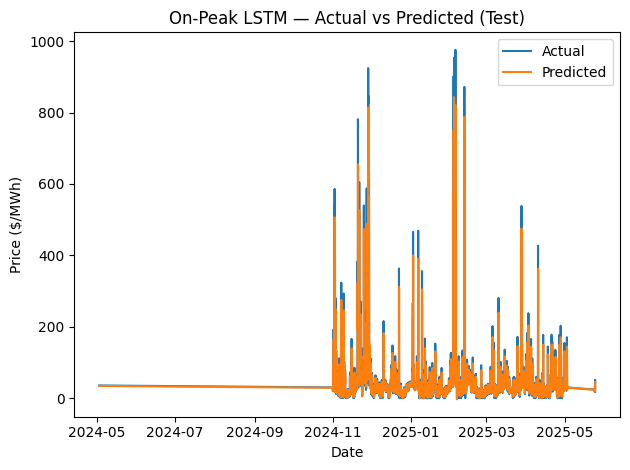

In [23]:
y_pred_s = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_s).ravel()
y_true = scaler_y.inverse_transform(y_test).ravel()

mae  = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = (np.abs((y_true - y_pred) / (y_true + 1e-8))).mean() * 100

print(f"MAE : {mae:,.3f}")
print(f"RMSE: {rmse:,.3f}")
print(f"MAPE: {mape:,.2f}%")

# Match with datetime index for plotting
test_index = test_df.index[LOOKBACK:]  # align to y_test
plot_df = pd.DataFrame({"Actual": y_true, "Predicted": y_pred}, index=test_index)

plt.figure()
plt.plot(plot_df.index, plot_df["Actual"], label="Actual")
plt.plot(plot_df.index, plot_df["Predicted"], label="Predicted")
plt.xlabel("Date"); plt.ylabel("Price ($/MWh)")
plt.title("On-Peak LSTM — Actual vs Predicted (Test)")
plt.legend(); plt.tight_layout(); plt.show()

Forecast for 168 hours

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


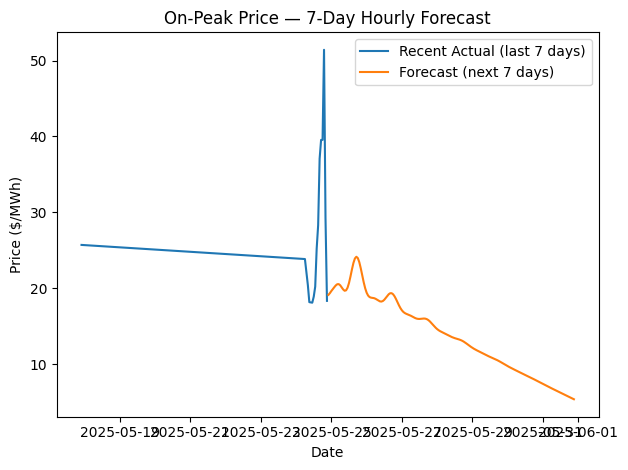

In [20]:
FORECAST_HOURS = 168
last_window = scaler_y.transform(df[["Price"]].iloc[-LOOKBACK:].values)  # shape (168, 1)
window = last_window.copy()
future_scaled = []

for _ in range(FORECAST_HOURS):
    inp = window.reshape(1, LOOKBACK, 1)
    next_scaled = model.predict(inp, verbose=0)[0, 0]
    future_scaled.append(next_scaled)
    # roll window
    window = np.vstack([window[1:], [[next_scaled]]])

future_prices = scaler_y.inverse_transform(np.array(future_scaled).reshape(-1,1)).ravel()

future_index = pd.date_range(df.index[-1] + pd.Timedelta(hours=1), periods=FORECAST_HOURS, freq="H")
forecast_df = pd.DataFrame({"Forecast_Price": future_prices}, index=future_index)

plt.figure()
plt.plot(df.index[-7*24:], df["Price"].iloc[-7*24:], label="Recent Actual (last 7 days)")
plt.plot(forecast_df.index, forecast_df["Forecast_Price"], label="Forecast (next 7 days)")
plt.xlabel("Date"); plt.ylabel("Price ($/MWh)")
plt.title("On-Peak Price — 7-Day Hourly Forecast")
plt.legend(); plt.tight_layout(); plt.show()

Save Artifacts

In [21]:
OUT_DIR = "/mnt/data/On_Peak_LSTM_Output"
os.makedirs(OUT_DIR, exist_ok=True)
model.save(os.path.join(OUT_DIR, "on_peak_model.keras"))
pd.DataFrame({"min_": scaler_y.min_, "scale_": scaler_y.scale_.ravel()}).to_csv(
    os.path.join(OUT_DIR, "scaler_y_min_scale.csv"), index=False
)
plot_df.to_csv(os.path.join(OUT_DIR, "test_pred_vs_actual.csv"))
forecast_df.to_csv(os.path.join(OUT_DIR, "on_peak_7day_hourly_forecast.csv"))

print(f"Artifacts saved in: {OUT_DIR}")

Artifacts saved in: /mnt/data/On_Peak_LSTM_Output
